In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc

In [3]:
df = pd.read_csv('../datasets/churn_preprocessed.csv')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,True,4.0,Mobile,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,True,NaN,Mobile,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,True,NaN,Mobile,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,True,0.0,Mobile,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,True,0.0,Mobile,1,12.0,Credit Card,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [4]:
print(df['Churn'].dtype)
print()
print(df['Churn'].value_counts())

bool

Churn
False    4682
True      948
Name: count, dtype: int64


In [5]:
# feature / target 분리
X = df.drop('Churn', axis=1)
y = df['Churn']

In [6]:
# 데이터 타입별 컬럼 분리
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns:")
print(list(categorical_cols))
print()

print("Numerical columns:")
print(list(numerical_cols))

Categorical columns:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Numerical columns:
['CustomerID', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


In [7]:
#train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4504, 19)
X_test shape: (1126, 19)
y_train shape: (4504,)
y_test shape: (1126,)


## 전처리
- 수치형: median imputation + scaling
- 범주형: most_frequent imputation + one-hot encoding

In [8]:
# 전처리 파이프라인 정의
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [9]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print("전처리 후 X_train shape:", X_train_preprocessed.shape)
print("전처리 후 X_test shape:", X_test_preprocessed.shape)

전처리 후 X_train shape: (4504, 31)
전처리 후 X_test shape: (1126, 31)


## PCA

In [10]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_preprocessed.toarray() if hasattr(X_train_preprocessed, "toarray") else X_train_preprocessed)
X_test_pca = pca.transform(X_test_preprocessed.toarray() if hasattr(X_test_preprocessed, "toarray") else X_test_preprocessed)

explained_variance = pca.explained_variance_ratio_
explained_variance

array([1.57330389e-01, 1.02351522e-01, 8.14804021e-02, 6.58050296e-02,
       6.29622934e-02, 5.98099314e-02, 5.80137154e-02, 5.51899809e-02,
       4.97224224e-02, 4.31696865e-02, 3.75173253e-02, 2.94933293e-02,
       2.84519564e-02, 2.62264568e-02, 2.41823152e-02, 2.20785307e-02,
       2.09655077e-02, 1.93120458e-02, 1.67333253e-02, 9.30771930e-03,
       8.48666061e-03, 7.97810092e-03, 4.91464052e-03, 4.45366342e-03,
       3.50690837e-03, 5.56141280e-04, 6.14237837e-18, 4.60477738e-19,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

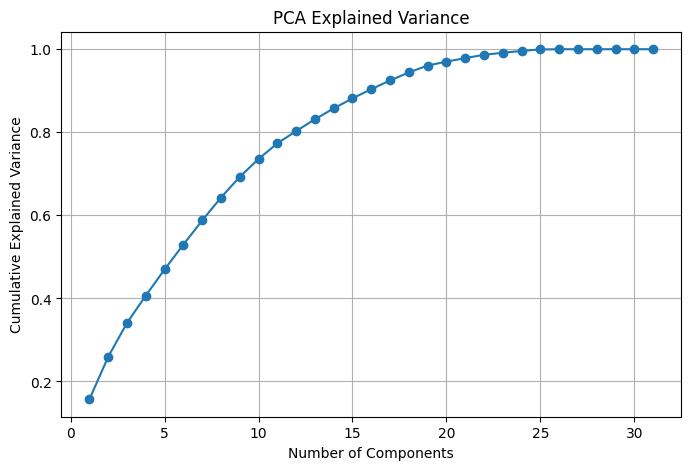

In [11]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

- PCA를 적용해도 모델의 성능이 향상되지 않으며, 불필요한 복잡성을 초래하고 중요한 정보를 잃게 됨

## 평가 함수

In [12]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print('Classification Report')
    print('-----------------------')
    print()
    print(classification_report(y_test, y_pred))
    print()

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=True)
    recall = recall_score(y_test, y_pred, pos_label=True)
    f1 = f1_score(y_test, y_pred, pos_label=True)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(model_name)
    print('---------------------')
    print(f'Accuracy:   {accuracy:.4f}')
    print(f'Precision:  {precision:.4f}')
    print(f'Recall:     {recall:.4f}')
    print(f'F1 Score:   {f1:.4f}')
    print(f'ROC AUC:    {roc_auc:.4f}')

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Not Churn', 'Churn'],
        yticklabels=['Not Churn', 'Churn']
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc_curve = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve (area = {roc_auc_curve:.2f})')
    plt.plot([0, 1], [0, 1], lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }

## Logistic Regression

Classification Report
-----------------------

              precision    recall  f1-score   support

       False       0.91      0.97      0.94       936
        True       0.76      0.53      0.63       190

    accuracy                           0.89      1126
   macro avg       0.83      0.75      0.78      1126
weighted avg       0.88      0.89      0.88      1126


Logistic Regression
---------------------
Accuracy:   0.8925
Precision:  0.7594
Recall:     0.5316
F1 Score:   0.6254
ROC AUC:    0.8847


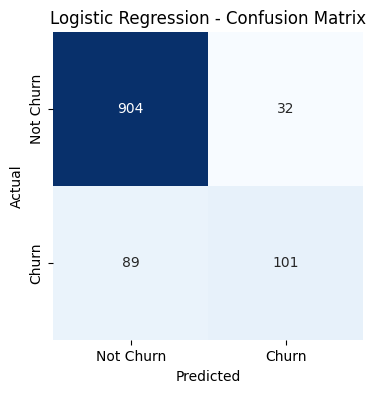

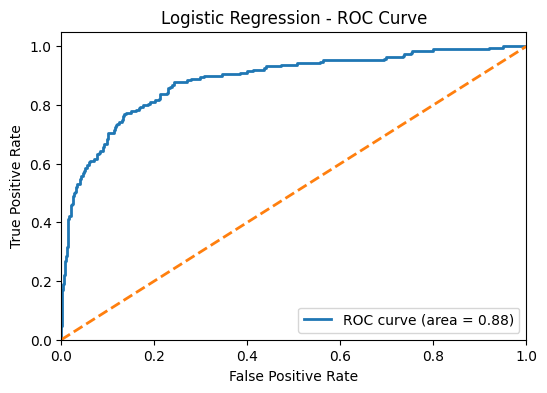

In [13]:
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_preprocessed, y_train)

lr_results = evaluate_model(model_lr, X_test_preprocessed, y_test, 'Logistic Regression')

## Decision Tree

Classification Report
-----------------------

              precision    recall  f1-score   support

       False       0.98      0.97      0.98       936
        True       0.86      0.92      0.89       190

    accuracy                           0.96      1126
   macro avg       0.92      0.95      0.93      1126
weighted avg       0.96      0.96      0.96      1126


Decision Tree
---------------------
Accuracy:   0.9609
Precision:  0.8578
Recall:     0.9211
F1 Score:   0.8883
ROC AUC:    0.9450


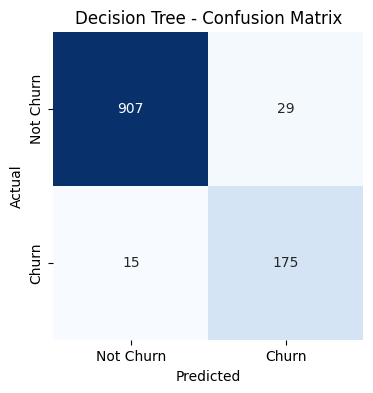

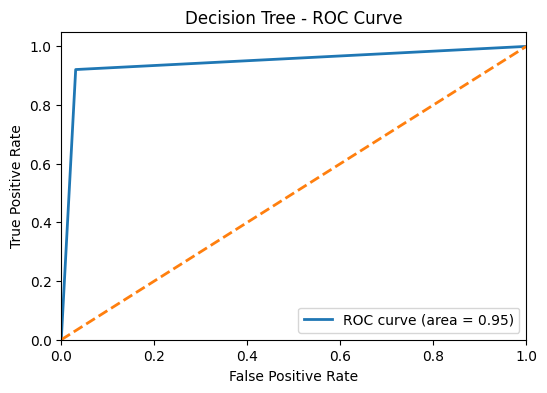

In [14]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_preprocessed, y_train)

dt_results = evaluate_model(model_dt, X_test_preprocessed, y_test, 'Decision Tree')

## Random Forest

Classification Report
-----------------------

              precision    recall  f1-score   support

       False       0.97      1.00      0.98       936
        True       0.99      0.85      0.91       190

    accuracy                           0.97      1126
   macro avg       0.98      0.92      0.95      1126
weighted avg       0.97      0.97      0.97      1126


Random Forest
---------------------
Accuracy:   0.9725
Precision:  0.9877
Recall:     0.8474
F1 Score:   0.9122
ROC AUC:    0.9979


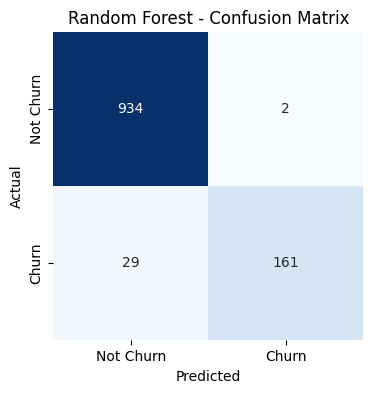

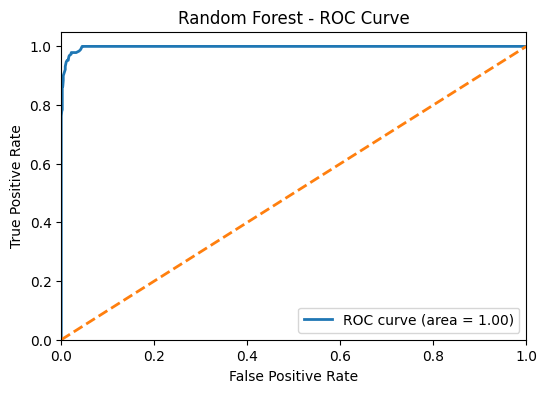

In [15]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_preprocessed, y_train)

rf_results = evaluate_model(model_rf, X_test_preprocessed, y_test, 'Random Forest')

## XGBoost

Classification Report
-----------------------

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       936
           1       0.97      0.93      0.95       190

    accuracy                           0.98      1126
   macro avg       0.98      0.96      0.97      1126
weighted avg       0.98      0.98      0.98      1126


XGBoost
---------------------
Accuracy:   0.9822
Precision:  0.9670
Recall:     0.9263
F1 Score:   0.9462
ROC AUC:    0.9972


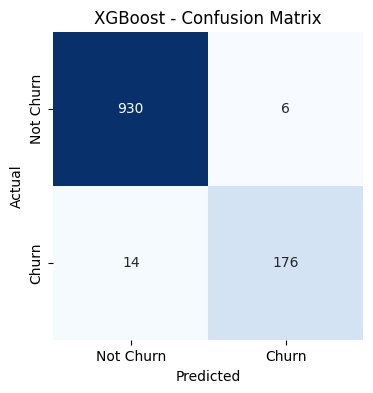

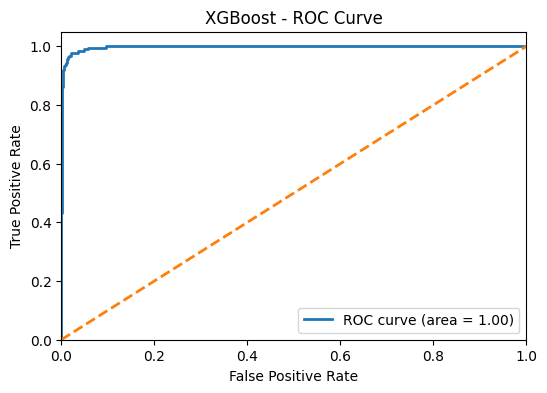

In [16]:
y_train_xgb = y_train.astype(int)
y_test_xgb = y_test.astype(int)

model_xgb = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_xgb.fit(X_train_preprocessed, y_train_xgb)

xgb_results = evaluate_model(model_xgb, X_test_preprocessed, y_test_xgb, 'XGBoost')

## CatBoost

In [17]:
model_cb = CatBoostClassifier(
    random_state=42,
    verbose=0,
    train_dir='../outputs/catboost_info'
)

model_cb.fit(X_train_preprocessed, y_train)

CatBoostClassifier(random_state=42, verbose=0)

Classification Report
-----------------------

              precision    recall  f1-score   support

       False       0.96      0.99      0.97       936
        True       0.93      0.81      0.86       190

    accuracy                           0.96      1126
   macro avg       0.94      0.90      0.92      1126
weighted avg       0.96      0.96      0.96      1126


CatBoost
---------------------
Accuracy:   0.9565
Precision:  0.9273
Recall:     0.8053
F1 Score:   0.8620
ROC AUC:    0.9915


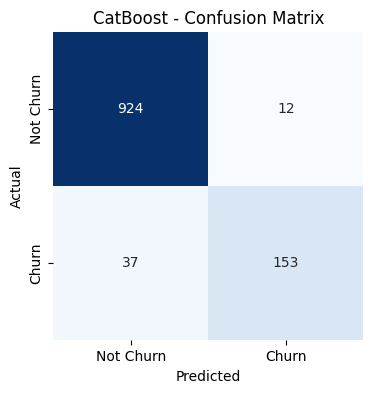

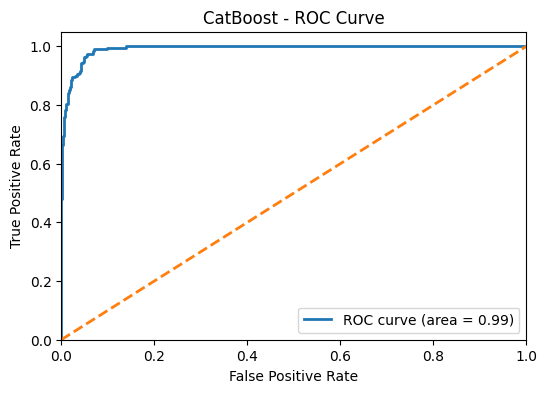

In [18]:
cb_results = evaluate_model(
    model_cb,
    X_test_preprocessed,
    y_test,
    'CatBoost'
)

### DEEPLEARNING(MLP)

Classification Report
-----------------------

              precision    recall  f1-score   support

       False       0.99      0.99      0.99       936
        True       0.93      0.95      0.94       190

    accuracy                           0.98      1126
   macro avg       0.96      0.97      0.97      1126
weighted avg       0.98      0.98      0.98      1126


MLPClassifier
---------------------
Accuracy:   0.9805
Precision:  0.9330
Recall:     0.9526
F1 Score:   0.9427
ROC AUC:    0.9936


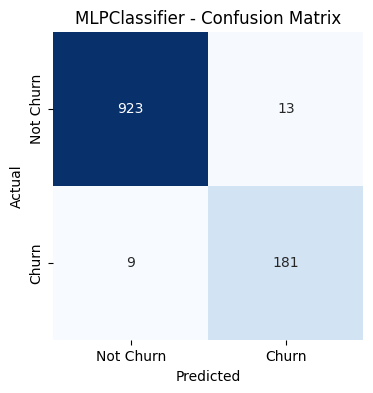

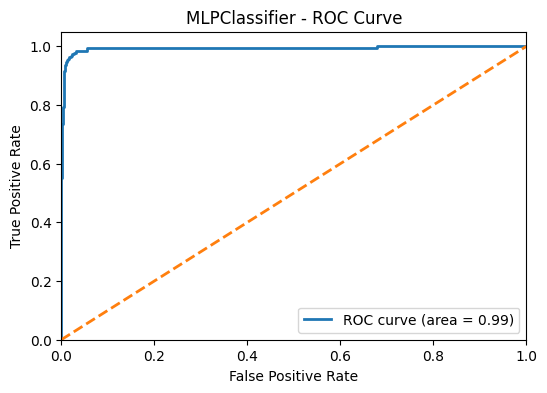

In [19]:
from sklearn.neural_network import MLPClassifier
model_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='adaptive',
    max_iter=300,
    random_state=42
)

model_mlp.fit(X_train_preprocessed, y_train)

mlp_results = evaluate_model(model_mlp, X_test_preprocessed, y_test, 'MLPClassifier')

## 모델 성능 비교

In [20]:
results_df = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,
    xgb_results,
    cb_results,
    mlp_results
])

results_df.sort_values(by='ROC AUC', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.972469,0.987730,0.847368,0.912181,0.997914
3,XGBoost,0.982238,0.967033,0.926316,0.946237,0.997228
5,MLPClassifier,0.980462,0.932990,0.952632,0.942708,0.993629
4,CatBoost,0.956483,0.927273,0.805263,0.861972,0.991515
1,Decision Tree,0.960924,0.857843,0.921053,0.888325,0.945035
0,Logistic Regression,0.892540,0.759398,0.531579,0.625387,0.884666


In [21]:
best_model_row = results_df.sort_values(by='ROC AUC', ascending=False).iloc[0]
print("Best model based on ROC AUC:")
print(best_model_row)

Best model based on ROC AUC:
Model        Random Forest
Accuracy          0.972469
Precision          0.98773
Recall            0.847368
F1 Score          0.912181
ROC AUC           0.997914
Name: 2, dtype: object


### 정리
- 총 4개의 모델(로지스틱 회귀, 결정 트리, 랜덤 포레스트, XGBoost)을 학습
- 데이터는 결측치 대체(imputation), 스케일링(scaling), 원-핫 인코딩(one-hot encoding)을 통해 전처리되었다.
- PCA도 검토되었지만, 최종 분류는 전처리된 전체 변수(feature) 데이터를 기반으로 수행되었다.
- 최종 모델 비교에서는 특히 Recall, F1 Score, ROC AUC에 중점을 두어야 한다. 이는 고객 이탈 예측이 불균형 데이터 분류 문제이기 때문이다.

In [22]:
import pickle
import os
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier

# 폴더 생성
os.makedirs('models', exist_ok=True)

# 최종 모델 (CatBoost 기준)
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(
        random_state=42,
        verbose=0,
        train_dir='../outputs/catboost_info'
    ))
])

final_pipeline.fit(X_train, y_train)

with open('../artifacts/churn_model.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)

print("모델 저장 완료: ../artifacts/churn_model.pkl")

모델 저장 완료: ../artifacts/churn_model.pkl


In [23]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

pipeline_lr.fit(X_train, y_train)

with open('../artifacts/model_lr.pkl', 'wb') as f:
    pickle.dump(pipeline_lr, f)

print("Logistic Regression 저장 완료")

Logistic Regression 저장 완료


In [24]:
from sklearn.tree import DecisionTreeClassifier

pipeline_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

pipeline_dt.fit(X_train, y_train)

with open('../artifacts/model_dt.pkl', 'wb') as f:
    pickle.dump(pipeline_dt, f)

print("Decision Tree 저장 완료")

Decision Tree 저장 완료


In [25]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline_rf.fit(X_train, y_train)

with open('../artifacts/model_rf.pkl', 'wb') as f:
    pickle.dump(pipeline_rf, f)

print("Random Forest 저장 완료")

Random Forest 저장 완료


In [26]:
import xgboost as xgb

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

pipeline_xgb.fit(X_train, y_train.astype(int))  # XGB는 int 추천

with open('../artifacts/model_xgb.pkl', 'wb') as f:
    pickle.dump(pipeline_xgb, f)

print("XGBoost 저장 완료")

XGBoost 저장 완료
